# Дипломна робота
## КОМП'ЮТЕРНА АКАДЕМІЯ IT STEP

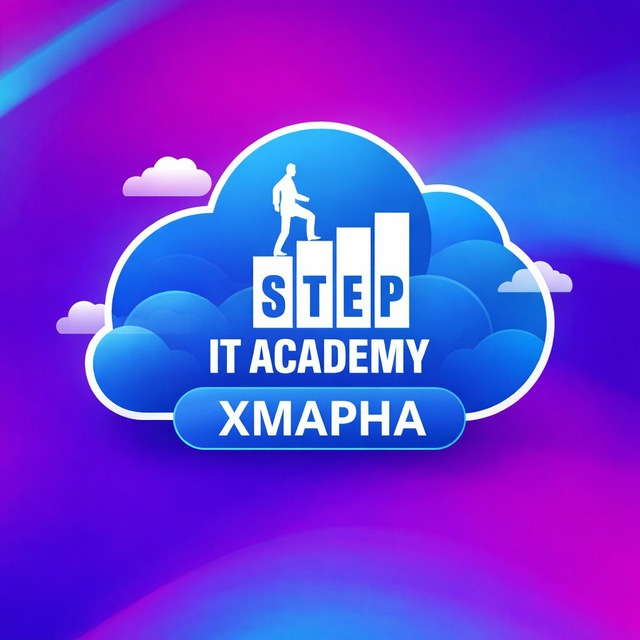

**Курс:** Штучний інтелект з використанням Python

**Тема:** Інтелектуальна система аналізу та прогнозування продажів на основі неструктурованих Excel-звітів

**Група:** AI+Python52

**Викладач:** Галиш Антон

**Виконав:** Токар Сергій
## Мета роботи:
Розробка пайплайну для обробки "сирих" Excel-файлів, проведення розвідувального аналізу (EDA), сегментація товарів/клієнтів (Clustering) та побудова моделі прогнозування продажів (ML).

# Підготовка середовища Colab

Ідемо шляхом «тонкого» ноутбука: в ipynb-файлі тільки підготовка, конфігурація, запуск пайплайна і демонстрація результатів. Вся основна логіка в py-файлах репозиторію GitHub (так зручніше тестувати й підтримувати), усі складні і не дуже перетворення винесені в окремі модулі.

### Клонуємо репозиторій з кодом та даними

In [1]:
import os, sys, pathlib

REPO_URL = "https://github.com/100car/examination.git"
REPO_DIR = "examination"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
%cd {REPO_DIR}

# (Опційно) завжди тягнемо останні зміни
!git pull --ff-only


/content/examination
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 8 (delta 6), reused 8 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 685 bytes | 228.00 KiB/s, done.
From https://github.com/100car/examination
   f18a7ef..d7f55a1  main       -> origin/main
Updating f18a7ef..d7f55a1
Fast-forward
 DATA/config.yaml              | 2 +-
 DATA/step07_eda_normalized.py | 3 ++-
 2 files changed, 3 insertions(+), 2 deletions(-)


### Структура даних пайплайну:
```
DATA/
├─ SKU/
│  └─ sku_master.xlsx                 # Головний файл з інформацією по SKU
└─ SALES/
   ├─ SALES_REPORTS/                  # Вхідні звіти продажів по регіонах
   ├─ RECOGNIZED_SALES_REPORTS/       # Розпізнані звіти (евристики + LLM)
   ├─ MONTHLY_SALES_CORRECTED/        # Скориговані користувачем медіани
   ├─ REGIONAL_ARRIVALS/              # Вхідні надходження по регіонах
   ├─ TRANSIT_PLANNED_ARRIVALS/       # Планові надходження на транзитні склади
   ├─ TRANSIT_PLANNED_SHIPMENTS/      # Планові відвантаження з транзитних складів
   ├─ TRANSIT_STOCK_STATUS/           # Статуси залишків на транзитних складах
   ├─ RESULT/                         # Вихідні результати пайплайна
   │  └─ results.xlsx                 # зберігатимуться у цьому файлі
   └─ LOGS/                           # Детальні логи виконання
```

Пайплайн передбачає, що всі модулі працюють із цією структурою. Зараз відбулося завантаження необхідних файлів даних у вигляді таблиць Excel, "шматки" пайтонівського коду, файл "вимог" та конфігурації.


### Встановлюємо вимоги (requirements.txt)



In [2]:
!pip -q install -r DATA/requirements.txt

### Налаштовуємо секретний ключ (для LLM-моделі)

In [3]:
# GEMINI_API_KEY збережено через Colab > Secrets
import os
try:
    from google.colab import userdata
    key = userdata.get("GEMINI_API_KEY")
    if key:
        os.environ["GEMINI_API_KEY"] = key
except Exception:
    pass

# Перевіримо, що ключ є (не друкуємо його!)
HAS_GEMINI_KEY = bool(os.environ.get("GEMINI_API_KEY"))
print("GEMINI_API_KEY set:", HAS_GEMINI_KEY)


GEMINI_API_KEY set: True


### Конфігурація пайплайна

Щоб не хардкодити шляхи / параметри в коді, використовуємо окремий конфіг-файл.
Нижче — завантаження `config.yaml` (або дефолтний конфіг, якщо файла ще нема).

#### Примітка:

Файл config.yaml підготовлений для подальшого винесення параметрів пайплайну,
але в межах поточної реалізації всі ключові шляхи і параметри поки що зафіксовані в коді.

In [4]:
# Конфіг: читаємо config.yaml + дефолти (deep-merge) + готуємо змінні/директорії
from pathlib import Path
import yaml
import os

CFG_PATH = Path("config.yaml")

default_cfg = {
    "paths": {
        "data_root": "DATA",
        "sku_master": "DATA/SKU/sku_master.xlsx",
        "sales_reports_dir": "DATA/SALES/SALES_REPORTS",
        "result_dir": "DATA/SALES/RESULT",
        "result_workbook": "DATA/SALES/RESULT/results.xlsx",
    },
    "pipeline": {
        "debug": True,
        "llm_enabled": True,
    }
}

def deep_merge(base: dict, override: dict) -> dict:
    """Рекурсивно зливає словники: override має пріоритет."""
    out = dict(base)
    for k, v in (override or {}).items():
        if isinstance(v, dict) and isinstance(out.get(k), dict):
            out[k] = deep_merge(out[k], v)
        else:
            out[k] = v
    return out

user_cfg = {}
if CFG_PATH.exists():
    user_cfg = yaml.safe_load(CFG_PATH.read_text(encoding="utf-8")) or {}

cfg = deep_merge(default_cfg, user_cfg)

# 1) Авто-вимкнення LLM, якщо ключа нема
# HAS_GEMINI_KEY береться з попередньої комірки з секретом; якщо її не було — підстрахуємось:
HAS_GEMINI_KEY = globals().get("HAS_GEMINI_KEY", bool(os.environ.get("GEMINI_API_KEY")))

if cfg["pipeline"].get("llm_enabled", False) and not HAS_GEMINI_KEY:
    cfg["pipeline"]["llm_enabled"] = False
    print("⚠️ GEMINI_API_KEY не задано — LLM вимкнено (pipeline.llm_enabled=False).")

# 2) Зручні змінні для наступних кроків ноутбука
DATA_ROOT = Path(cfg["paths"]["data_root"])
RESULT_DIR = Path(cfg["paths"]["result_dir"])
RESULT_XLSX = Path(cfg["paths"]["result_workbook"])

# 3) Гарантуємо, що папка під results.xlsx існує
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# 4) Прокидуємо базові налаштування в env (щоб модулі могли читати, якщо захочеш)
os.environ["PIPELINE_DEBUG"] = "1" if cfg["pipeline"].get("debug") else "0"
os.environ["PIPELINE_LLM_ENABLED"] = "1" if cfg["pipeline"].get("llm_enabled") else "0"
os.environ["PIPELINE_RESULT_XLSX"] = str(RESULT_XLSX)

print("Config loaded ✅")
print("RESULT_XLSX =", RESULT_XLSX)
print("LLM enabled =", cfg["pipeline"]["llm_enabled"])

cfg


Config loaded ✅
RESULT_XLSX = DATA/SALES/RESULT/results.xlsx
LLM enabled = True


{'paths': {'data_root': 'DATA',
  'sku_master': 'DATA/SKU/sku_master.xlsx',
  'sales_reports_dir': 'DATA/SALES/SALES_REPORTS',
  'result_dir': 'DATA/SALES/RESULT',
  'result_workbook': 'DATA/SALES/RESULT/results.xlsx'},
 'pipeline': {'debug': True, 'llm_enabled': True}}

## STEP 01. Пакетний парсер Excel-звітів продажів по регіонам

Зчитуємо з папки
```
DATA/
└─ SALES/
   └─ SALES_REPORTS/                  
```
всі звіти продажів по регіонах (три: Україна, Узбекистан та Казахстан, - або менше). Якщо за допомогою евристичного аналізу не вдається розпізнати заголовки стовбчиків, то використовуємо LLM (Gemini API).
Важливі правила для обробки:
- Рядки без Symbol (артикула) НЕ переносимо у вихідний файл.
- Якщо у заголовках є "ОС" (після нормалізації -> "ос") — це Stock і регіон UZ визначається однозначно.
- Перед аналізом "розкриваємо" всі приховані колонки (hidden=False) і вже потім детектимо/рахуємо.
- TOTAL у вихідному файлі завжди перераховується як сума місяців.
Якщо у вхідному файлі був власний Total — підсвічуємо mismatch червоним.

In [5]:
!python DATA/build_results_workbook.py

STEP 1 | Build results workbook | 2026-01-26 15:45:37
OK   UA2025.xlsx                                              | det=H   | region=UA  | checked=1017 | mismatches=0    | saved=UA_UA2025_sales_recognized.xlsx
OK   25_12_30_Продажа_АМР_за_январь_декабрь_2025_г_.xls.xlsx  | det=H   | region=KZ  | checked=349  | mismatches=0    | saved=KZ_25_12_30_Продажа_АМР_за_январь_декабрь_2025_г_.xls_sales_recognized.xlsx
OK   amp monthly december.xlsx                                | det=LLM | region=UZ  | checked=598  | mismatches=0    | saved=UZ_amp monthly december_sales_recognized.xlsx
OK   | step=1 | saved=/content/examination/DATA/SALES/RESULT/results.xlsx
Проаналізовано: 3 файлів | Сформовано: 3 файлів (із них за допомогою LLM: 1)
OK   | step=1 | saved=/content/examination/DATA/SALES/RESULT/results.xlsx


## Результати першого етапу
У ході виконання модуля build_results_workbook сформовано зведений Excel-файл, що містить окремі аркуші зі звітами продаж по регіонам:
*   UA-sales (Україна))
*   UZ-sales (Узбекистан)
*   KZ-sales (Казахстан)

Кожен аркуш включає агреговані показники продажів відповідного регіону та використовується на наступних етапах обробки даних.

In [6]:
import pandas as pd
from pathlib import Path
import os

result_xlsx = Path(os.environ.get("PIPELINE_RESULT_XLSX", "DATA/SALES/RESULT/results.xlsx"))
assert result_xlsx.exists(), f"Results file not found: {result_xlsx}"

sheets = ["UA-sales", "UZ-sales", "KZ-sales"]

for sheet in sheets:
    print(f"\n📊 Sheet: {sheet}")
    df = pd.read_excel(result_xlsx, sheet_name=sheet)
    display(df.head())



📊 Sheet: UA-sales


,Symbol,количество товаров январь 2025 г,количество товаров февраль 2025 г,количество товаров март 2025 г,количество товаров апрель 2025 г,количество товаров май 2025 г,количество товаров июнь 2025 г,количество товаров июль 2025 г,количество товаров август 2025 г,количество товаров сентябрь 2025 г,количество товаров октябрь 2025 г,количество товаров ноябрь 2025 г,количество товаров декабрь 2025 г,Stock,TOTAL
0,PR-SEN-44-4125-000-SET,78.0,22.0,154.0,57.0,75.0,87.0,43.0,89.0,71.0,146.0,98.0,62.0,263.0,982.0
1,PR-SEN-44-4125-025-SET,32.0,11.0,26.0,11.0,21.0,44.0,9.0,19.0,16.0,26.0,14.0,11.0,83.0,240.0
2,PR-SEN-44-4125-050-SET,40.0,7.0,60.0,33.0,32.0,64.0,36.0,61.0,61.0,66.0,14.0,19.0,201.0,493.0
3,PR-SEN-44-4126-000-SET,16.0,1.0,4.0,4.0,14.0,19.0,15.0,-2.0,7.0,13.0,4.0,6.0,35.0,101.0
4,PR-SEN-44-4126-025-SET,1.0,0.0,2.0,3.0,2.0,0.0,0.0,-2.0,2.0,0.0,0.0,0.0,15.0,8.0



📊 Sheet: UZ-sales


,Symbol,янв,фев,мар,апр,май,июн,июл,авг,сен,окт,ноя,дек,Stock,TOTAL
0,JISU003-G-S-0,0,0,0,0,0,0,0,0,40,200,0,0,348,240
1,JKAM001-G-P-0,0,0,820,0,0,0,0,0,0,0,0,0,2400,820
2,JKAM001-G-S-0,0,0,0,0,0,0,0,0,0,0,0,0,12000,0
3,JLAD006-B-S-0,32,216,240,192,208,0,400,0,2128,192,0,0,0,3608
4,JLAD006-B-S-1,0,0,0,16,64,0,0,0,0,80,0,0,0,160



📊 Sheet: KZ-sales


,Symbol,январь 2025 г,февраль 2025 г,март 2025 г,апрель 2025 г,май 2025 г,июнь 2025 г,июль 2025 г,август 2025 г,сентябрь 2025 г,октябрь 2025 г,ноябрь 2025 г,декабрь 2025 г,Stock,TOTAL
0,PDAE014-A-0-D,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,PDAE014-B-0-N,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,PDAE013-S-0-H,0,0,30,0,0,0,0,0,0,0,0,0,78,30
3,PDAE014-B-0-H,0,0,6,0,0,0,0,0,0,0,12,0,192,18
4,PDAE002-A-0-0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Отримані результати підтверджують коректність формування регіональних звітів продажів. Структура даних є уніфікованою для всіх регіонів, що дозволяє використовувати сформований Excel-файл як вхідні дані для наступних етапів пайплайна.

## STEP 02. Формування регіональних надходжень товарів

На цьому етапі виконується побудова допоміжних аркушів із регіональними надходженнями товарів
(UA+, KZ+, UZ+), які використовуються для подальшої нормалізації та розрахунку скоригованих
місячних продажів.

Скрипт `regional_arrivals.py` виконує такі дії:
- зчитує зведену таблицю результатів продажів;
- нормалізує товарні коди (SKU) з використанням довідника `sku_master.xlsx`;
- агрегує надходження за регіонами;
- додає до Excel-файлу нові аркуші з регіональними надходженнями.

Результатом виконання є розширений файл результатів, що містить регіональні дані,
необхідні для подальших етапів аналітики.

In [7]:
!python DATA/regional_arrivals.py

STEP 2 | Build regional arrivals sheets | 2026-01-26 15:45:53
OK   | region=UA | in=48    | unique=48    | merged=0     | green=0    | red=2    | saved=UA+ | file=05.01.2025 UA.xlsx
OK   | region=KZ | in=269   | unique=192   | merged=77    | green=4    | red=0    | saved=KZ+ | file=KZ-12+order.xlsx
OK   | region=UZ | in=103   | unique=101   | merged=2     | green=0    | red=0    | saved=UZ+ | file=UZ_amp 2025.xlsx
OK   | step=2 | saved=/content/examination/DATA/SALES/RESULT/results.xlsx


## STEP 03. Нормалізація результатів та уніфікація місячних показників

На цьому етапі виконується фінальна нормалізація зведеного файлу результатів продажів.
Скрипт `normalize_results_workbook.py` приводить дані до єдиного формату,
придатного для подальшого аналізу та використання в моделях машинного навчання.

Основні дії скрипта:
- уніфікація назв місяців до стандартного формату  
  (`янв`, `фев`, `мар`, `апр`, `май`, `июн`, `июл`, `авг`, `сен`, `окт`, `ноя`, `дек`);
- нормалізація товарних ідентифікаторів (`Symbol_normalized`);
- застосування місячних корекцій продажів (за наявності файлів корекцій);
- розрахунок скоригованих показників продажів;
- формування фінальних аркушів `*-normalized`.

Отримані таблиці представляють собою стандартизовані часові ряди,
готові для статистичного аналізу, кластеризації та прогнозування попиту.


In [8]:
!python DATA/normalize_results_workbook.py --include-arrivals-added-col

STEP 3 | Normalize results workbook | 2026-01-26 15:45:56
OK   | region=UA | in=1017  | unique=1017  | merged=0     | green=0    | red=25   | arrivals_added=46   | saved=UA-normalized
OK   | region=KZ | in=349   | unique=345   | merged=4     | green=24   | red=0    | arrivals_added=172  | saved=KZ-normalized
OK   | region=UZ | in=598   | unique=597   | merged=1     | green=5    | red=0    | arrivals_added=98   | saved=UZ-normalized
OK   | step=3 | corrections_file=кольца results (2).xlsx
OK   | region=UA | corrections=696   | applied=696   | changed=175   | not_found=0    
OK   | region=KZ | corrections=345   | applied=345   | changed=69    | not_found=0    
OK   | region=UZ | corrections=597   | applied=597   | changed=120   | not_found=0    
OK   | step=3 | saved=/content/examination/DATA/SALES/RESULT/results.xlsx


## STEP 04. Planned Shipments → лист `STOCKS-`

Скрипт читає 0..3 Excel-файли з `DATA/SALES/TRANSIT_PLANNED_SHIPMENTS`,
агрегує кількість по SKU, нормалізує артикули та (за наявності) валідуює їх через `DATA/SKU/sku_master.xlsx`.

Результат: створює або перезаписує лист **`STOCKS-`** у `DATA/SALES/RESULT/results.xlsx`
з колонками: `Symbol_raw | Symbol | Quantity`.

Розфарбовування:
- валідний SKU → без заливки
- виправлено через Mapping → зелений
- все ще невалідний → червоний

In [9]:
!python DATA/transit_planned_shipments.py

STEP 4 | Build planned shipments sheet (STOCKS-) | 2026-01-26 15:46:03
OK   | file=05.01.2025 UA.xlsx             | in=48    | unique=48    | merged=0     | green=0    | red=2    | saved=STOCKS-
OK   | file=KZ.xlsx                        | in=138   | unique=138   | merged=0     | green=4    | red=0    | saved=STOCKS-
OK   | step=4 | saved=/content/examination/DATA/SALES/RESULT/results.xlsx


## STEP 05. Побудова аркушу `RINGS_SUMMARY`

Скрипт будує лист **`RINGS_SUMMARY`** у `results.xlsx` на базі `SKU/sku_master.xlsx` (рядки `Name == 1`),
а далі підтягує транзитні залишки/сировину/планові приходи з папок у `DATA/SALES/`.

Наприкінці додає колонки:
- `Order_1`, `Order_2`, `Order_3` (порожні для ручного вводу)
- `Total Available` (формула суми всіх “даних” колонок зліва)

In [10]:
!python DATA/rings_summary.py

STEP 5a | Побудова RINGS_SUMMARY | 2026-01-26 15:46:06
OK | step=5a | sheet=RINGS_SUMMARY | rows=247 | saved=/content/examination/DATA/SALES/RESULT/results.xlsx
STEP 5b | Заповнення з sets + перевірка сум (5c) | 2026-01-26 15:46:09
WRN | step=5b | sheet=Товары на складе | skipped | Лист 'Товары на складе': не знайдено колонки SKU/Quantity
OK | step=5b | saved=/content/examination/DATA/SALES/RESULT/results.xlsx | mapped_total=0 | missing_total=0
STEP 5d | Заповнення з surowce + перевірка в units | 2026-01-26 15:46:11
OK | step=5d | sheet=LWC+PE               | groups=58   | filled=59   | mapped=0   | missing=0   | split=1  | sum_min_units=  735084 | sum_results_units=  735084 | diff_units=       0
OK | step=5d | sheet=Monika               | groups=20   | filled=20   | mapped=0   | missing=0   | split=0  | sum_min_units=   26112 | sum_results_units=   26112 | diff_units=       0
OK | step=5e | sheet=STOCKS- (results) | in=60     | filled=60     | missing=0      | sum_expected=   -6405 | 

## STEP 06. Прогноз дефіциту поршневих кілець (Excel формули) → NEED_M1..NEED_M30

На цьому етапі додається прогноз дефіциту поршневих кілець на N місяців вперед
у вигляді **формул Excel** без “жорстких” чисел.

Перевага такого підходу:
- при зміні `Month_sales` або `Stock` на листах `UA-normalized / KZ-normalized / UZ-normalized`
  прогноз у `RINGS_SUMMARY` перераховується автоматично.

Логіка для кожного регіону і місяця `m`:
- `deficit = m * Month_sales - Stock`
- `need_region_m = IF(deficit > 0, -deficit, 0)`

Потім враховується загальний ресурс:
- `need_total_m = MIN(0, TotalAvailable + need_UA_m + need_KZ_m + need_UZ_m)`

Інтерпретація:
- `0` → дефіциту немає
- `< 0` → дефіцит (скільки не вистачає)

Додатково застосовується умовне форматування: значення `< 0` підсвічуються червоним.


In [11]:
!python DATA/rings_forecast_excel.py --months 30


STEP 8 | Прогноз наявності поршневих кілець | months=30
OK | updated: /content/examination/DATA/SALES/RESULT/results.xlsx | forecast_months=30


## Фінальний результат: лист `RINGS_SUMMARY` (що отримуємо в результаті)

Нижче наведено перші 8 рядків фінального файлу `results.xlsx`.
Таблиця містить **обчислені в Excel** показники доступності та прогнозу дефіциту, може безпосередньо використовуватись для прийняття рішень щодо замовлення товарів.



In [12]:
import pandas as pd
from pathlib import Path

results_path = Path("DATA/SALES/results-final.xlsx")

df = pd.read_excel(
    results_path,
    sheet_name="RINGS_SUMMARY",
    engine="openpyxl"
)

df = df.fillna("")

display(df.head(8))


,Symbol,Brand,Group1,Group2,LWC+PE,Monika,STOCKS-,SL1642509,SL1692601,SUP25459,...,NEED_M21,NEED_M22,NEED_M23,NEED_M24,NEED_M25,NEED_M26,NEED_M27,NEED_M28,NEED_M29,NEED_M30
0,PR-CHE-49-1405-000-SET,CHE,1405,19-1405-000,,,,,,,...,-1038.0,-1098.0,-1158.0,-1218.0,-1278.0,-1338.0,-1398.0,-1458.0,-1518.0,-1578.0
1,PR-CHE-49-1405-025-SET,CHE,1405,19-1405-025,,,,,,,...,-214.0,-228.0,-242.0,-256.0,-270.0,-284.0,-298.0,-312.0,-326.0,-340.0
2,PR-CHE-49-1405-050-SET,CHE,1405,19-1405-050,,,,,,,...,-240.0,-254.0,-268.0,-282.0,-296.0,-310.0,-324.0,-338.0,-352.0,-366.0
3,PR-CHE-49-1590-000-SET,CHE,1590,19-1590-000,,,,,,,...,-303.1,-322.2,-341.3,-360.4,-379.5,-398.6,-417.7,-436.8,-455.9,-475.0
4,PR-CHE-49-1590-025-SET,CHE,1590,19-1590-025,,,,,,,...,-287.9,-303.8,-319.7,-335.6,-351.5,-367.4,-383.3,-399.2,-415.1,-431.0
5,PR-CHE-49-1590-050-SET,CHE,1590,19-1590-050,,,-10.0,,,,...,-330.1,-349.2,-368.3,-387.4,-406.5,-425.6,-444.7,-463.8,-482.9,-502.0
6,PR-CHE-47-3549-000-SET,CHE,3549,17-3549-000,,,,,,,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,PR-CHE-47-3549-025-SET,CHE,3549,17-3549-025,,,,,,,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## STEP 07. EDA для "нормалізованих" аркушів (кільця поршневі: SKU з заданим префіксом `PR-`)

Мета: виконати EDA-аналіз для нормалізованих продажів по регіонах.

Робимо:
- читаємо всі аркуші `*-normalized` (UA/KZ/UZ)
- відбираємо SKU за префіксами з `config.yaml` (`filters.include_prefixes`, за замовчуванням `["PR-"]`)
- формуємо датасет у “довгому форматі” (region, Symbol_normalized, month, value)
- рахуємо агрегатні статистики
- будуємо графіки: гістограми та “ящики з вусами” (boxplot)

Артефакти зберігаються у `DATA/EDA/`:
- `normalized_long.csv`
- `normalized_summary_by_region.csv`
- `symbols_included_<REGION>.csv`, `symbols_excluded_<REGION>.csv`
- `plots/*.png`


In [13]:
!python DATA/step07_eda_normalized.py

STEP 7 | EDA (*-normalized) | long-format + агрегати + графіки
OK | STEP 7 завершено
- long:      DATA/EDA/normalized_long.csv
- summary:   DATA/EDA/normalized_summary_by_region.csv
- plots:     DATA/EDA/plots


## Gallery: графіки EDA (DATA/EDA/plots)

Відображаємо “плиткою” прямо в Colab всі PNG-графіки, які згенерував EDA-модуль.


In [14]:
from pathlib import Path
from IPython.display import display
import ipywidgets as widgets

plots_dir = Path("DATA/EDA/plots")
pngs = sorted(plots_dir.glob("*.png"))

if not plots_dir.exists():
    print(f"Папку не знайдено: {plots_dir} (спочатку запусти EDA-модуль)")
elif not pngs:
    print(f"У папці немає PNG: {plots_dir} (EDA-модуль не згенерував графіки?)")
else:
    items = []
    for p in pngs:
        img = widgets.Image(value=p.read_bytes(), format="png")
        title = widgets.HTML(f"<b>{p.name}</b>")
        box = widgets.VBox([title, img], layout=widgets.Layout(
            border="1px solid #ddd",
            padding="6px",
            margin="6px",
            width="360px"
        ))
        items.append(box)

    grid = widgets.GridBox(
        items,
        layout=widgets.Layout(
            grid_template_columns="repeat(2, 360px)",  # 2 колонки
            grid_gap="10px"
        )
    )
    display(grid)


GridBox(children=(VBox(children=(HTML(value='<b>box_monthly_value_by_region.png</b>'), Image(value=b'\x89PNG\r…

## STEP 08. Аналіз одного SKU по регіонах

Мета: на прикладі одного SKU показати різницю продажів між регіонами UA/KZ/UZ.

SKU береться так:
- `analysis.sku_example` з `config.yaml` (якщо задано)
- інакше автоматично береться перший SKU з потрібним префіксом у `UA-normalized`

Результат:
- графік `DATA/EDA/plots/sku_<SKU>_3regions.png`
- короткий висновок у консолі


In [15]:
!python DATA/step08_sku_region_analysis.py

STEP 08 | Аналіз одного SKU по регіонах (UA/KZ/UZ)

SKU: PR-DAE-37-1402-025-SET
region  TOTAL  Stock  Month_sales
    UA    0.0    0.0          0.0

Висновок:
- Різниця між регіонами невелика (≈1.00x). Для більш показового прикладу зміни analysis.sku_example у config.yaml.
- Графік: DATA/EDA/plots/sku_PR-DAE-37-1402-025-SET_3regions.png
OK | STEP 08 завершено


### Автоматичний вибір показового SKU + красива візуалізація по регіонах

1) Знаходимо PR-SKU, де середні продажі UA/KZ/UZ відрізняються найбільше.
2) Будуємо презентаційний графік (стовпчики по регіонах + пунктир середнього).

примітка
--------
ЗРОБИТИ ФУНКЦІЄЮ! ЗАШИТИ В КОНФІГ!!!


,SKU,mean_UA,mean_KZ,mean_UZ,ratio_max_min,mean_std,total_sum_3reg
8,PR-DAE-47-3538-000-SET,1.333333,0.000000,26.250000,2.625000e+10,12.072377,331.0
7,PR-DAE-39-1401-100-SET,0.333333,0.000000,12.416667,1.241667e+10,5.776309,153.0
14,PR-DAE-47-3548-000-SET,9.750000,0.000000,0.000000,9.750000e+09,4.596194,117.0
89,PR-WOL-49-5657-050-SET,0.250000,8.833333,0.000000,8.833333e+09,4.106416,109.0
15,PR-DAE-47-3548-025-SET,4.500000,0.000000,0.000000,4.500000e+09,2.121320,54.0
2,PR-DAE-37-1401-075-SET,0.000000,0.166667,3.250000,3.250000e+09,1.494331,41.0
13,PR-DAE-49-3538-100-SET,1.750000,0.000000,2.750000,2.750000e+09,1.136515,54.0
0,PR-CUM-44-0812-000-SET,1.916667,0.916667,0.000000,1.916667e+09,0.782722,34.0
3,PR-DAE-39-1401-000-SET,6.666667,1.583333,5454.333333,3.444842e+03,2569.253686,65551.0
4,PR-DAE-39-1401-025-SET,3.416667,1.916667,3022.750000,1.577087e+03,1423.681068,36337.0



✅ Обрано показовий SKU: PR-DAE-47-3538-000-SET


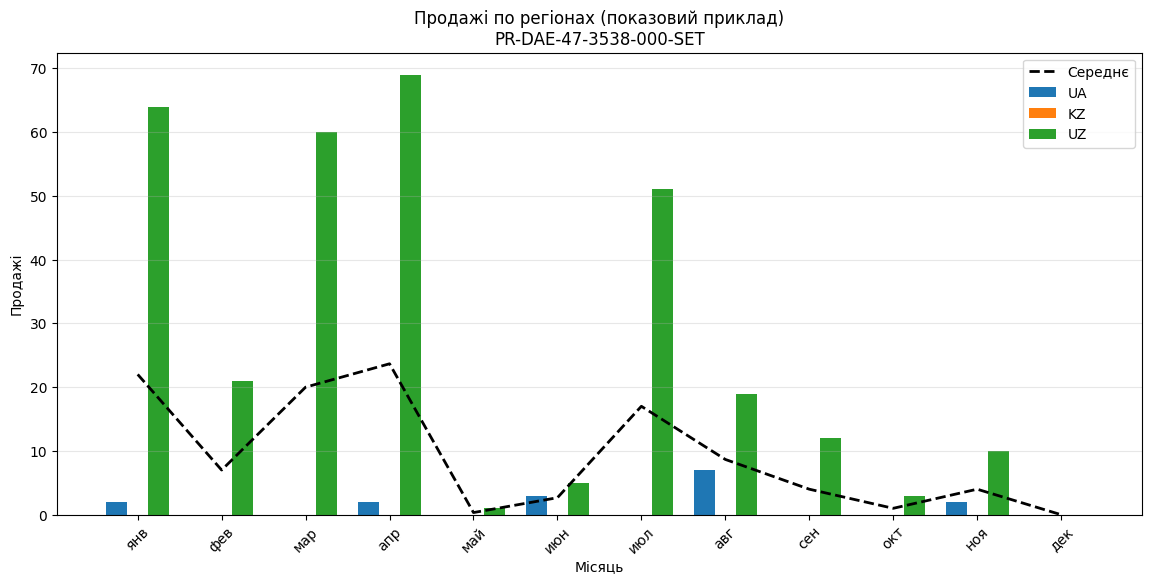

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

results_path = Path("DATA/SALES/RESULT/results.xlsx")
MONTHS = ["янв","фев","мар","апр","май","июн","июл","авг","сен","окт","ноя","дек"]

def load_region(region):
    df = pd.read_excel(results_path, sheet_name=f"{region}-normalized", engine="openpyxl")
    key = "Symbol_normalized" if "Symbol_normalized" in df.columns else "Symbol"
    cols = [key] + [m for m in MONTHS if m in df.columns]
    df = df[cols].copy().rename(columns={key: "SKU"})
    df["SKU"] = df["SKU"].astype(str).str.strip()
    df = df[df["SKU"].str.startswith("PR-")].copy()
    for m in MONTHS:
        df[m] = pd.to_numeric(df.get(m, 0), errors="coerce").fillna(0.0)
    df["mean"] = df[MONTHS].mean(axis=1)
    df["sum"] = df[MONTHS].sum(axis=1)
    return df

ua = load_region("UA")
kz = load_region("KZ")
uz = load_region("UZ")

# беремо SKU, які є у всіх трьох регіонах
cand = ua[["SKU","mean","sum"]].rename(columns={"mean":"mean_UA","sum":"sum_UA"}) \
    .merge(kz[["SKU","mean","sum"]].rename(columns={"mean":"mean_KZ","sum":"sum_KZ"}), on="SKU", how="inner") \
    .merge(uz[["SKU","mean","sum"]].rename(columns={"mean":"mean_UZ","sum":"sum_UZ"}), on="SKU", how="inner")

# відсікаємо нульові (щоб не вибрати “плоскі” SKU)
cand["total_sum_3reg"] = cand["sum_UA"] + cand["sum_KZ"] + cand["sum_UZ"]
cand = cand[cand["total_sum_3reg"] >= 30].copy()   # поріг можна: 10/30/50

# показовість: max/min + std
means = cand[["mean_UA","mean_KZ","mean_UZ"]].values
cand["mean_max"] = means.max(axis=1)
cand["mean_min"] = means.min(axis=1)
cand["mean_std"] = means.std(axis=1)
cand["ratio_max_min"] = (cand["mean_max"] + 1e-9) / (cand["mean_min"] + 1e-9)

top = cand.sort_values(["ratio_max_min","mean_std","total_sum_3reg"], ascending=False).head(20)
display(top[["SKU","mean_UA","mean_KZ","mean_UZ","ratio_max_min","mean_std","total_sum_3reg"]])

best_sku = top.iloc[0]["SKU"]
print("\n✅ Обрано показовий SKU:", best_sku)

def months_series(df_region, sku):
    r = df_region[df_region["SKU"] == sku]
    if r.empty:
        return np.zeros(12)
    r = r.iloc[0]
    return np.array([float(r[m]) for m in MONTHS], dtype=float)

ua_y = months_series(ua, best_sku)
kz_y = months_series(kz, best_sku)
uz_y = months_series(uz, best_sku)
mean_y = np.mean([ua_y, kz_y, uz_y], axis=0)

# --- красивий графік ---
x = np.arange(len(MONTHS))
w = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - w, ua_y, width=w, label="UA")
plt.bar(x,     kz_y, width=w, label="KZ")
plt.bar(x + w, uz_y, width=w, label="UZ")

plt.plot(x, mean_y, color="black", linestyle="--", linewidth=2, label="Середнє")

plt.xticks(x, MONTHS, rotation=45)
plt.ylabel("Продажі")
plt.xlabel("Місяць")
plt.title(f"Продажі по регіонах (показовий приклад)\n{best_sku}")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()


### Висновок (аналіз одного SKU по регіонах)

На прикладі SKU **PR-DAE-47-3538-000-SET** видно, що обсяги продажів суттєво відрізняються залежно від регіону.

- У регіоні **UZ** продажі стабільно вищі протягом більшості місяців,
  з піками у першій половині року.
- У регіонах **UA** та **KZ** продажі значно нижчі та мають епізодичний характер.
- Середня лінія підтверджує загальний тренд домінування регіону UZ.

Це свідчить про те, що **попит на даний SKU суттєво залежить від регіону**,
а отже доцільно застосовувати регіонально-орієнтоване планування запасів та продажів.


## STEP 09. KMeans кластеризація SKU

Мета: сегментувати PR-товари за профілем продажів.

Робимо:
- збираємо єдиний датасет по SKU, сумуючи UA+KZ+UZ
- стандартизуємо ознаки
- підбираємо k за:
  - методом “ліктя” (inertia)
  - метрикою silhouette
- навчаємо KMeans та додаємо `cluster_id`

Результат:
- `DATA/ML/clusters_pr.csv`
- `DATA/ML/plots/elbow.png`, `DATA/ML/plots/silhouette.png`
- лист `PR_CLUSTERS` у `results.xlsx`


In [18]:
!python DATA/step09_kmeans_clustering.py


STEP 09 | KMeans кластеризація SKU (PR-)
Обрано k=2 (максимум silhouette).
OK | STEP 09 завершено
- CSV:   DATA/ML/clusters_pr.csv
- sheet: PR_CLUSTERS у DATA/SALES/RESULT/results.xlsx
- plots: DATA/ML/plots


## Ілюстрація: підбір кількості кластерів (KMeans)

Нижче наведені графіки:
- **Elbow method** — залежність інерції від кількості кластерів
- **Silhouette score** — оцінка якості кластеризації

На основі цих графіків було обрано оптимальну кількість кластерів.


'elbow.png'

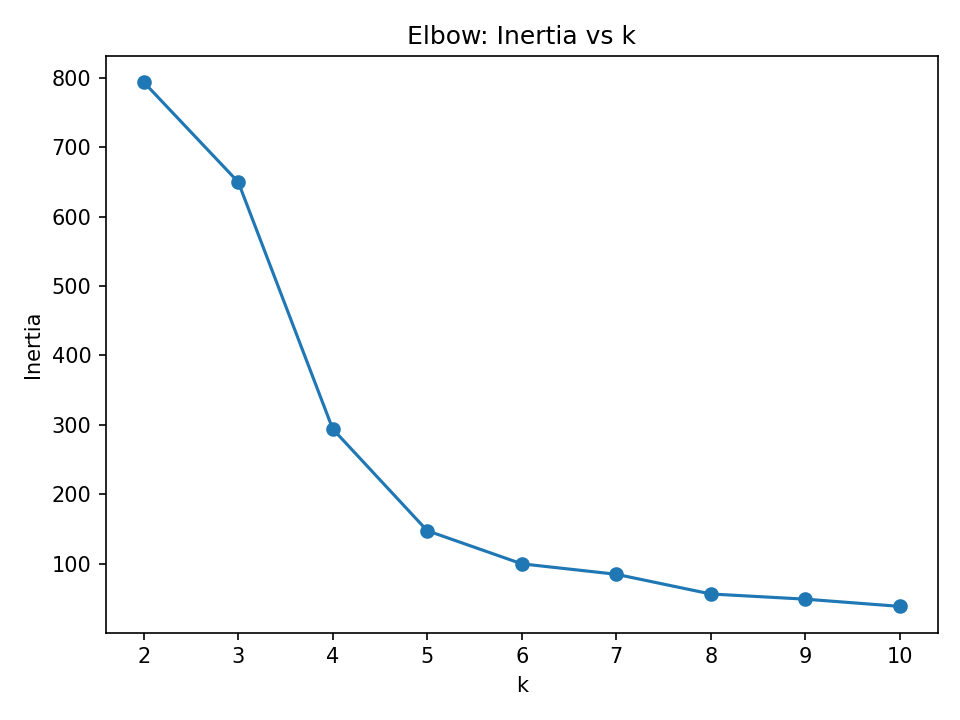

'silhouette.png'

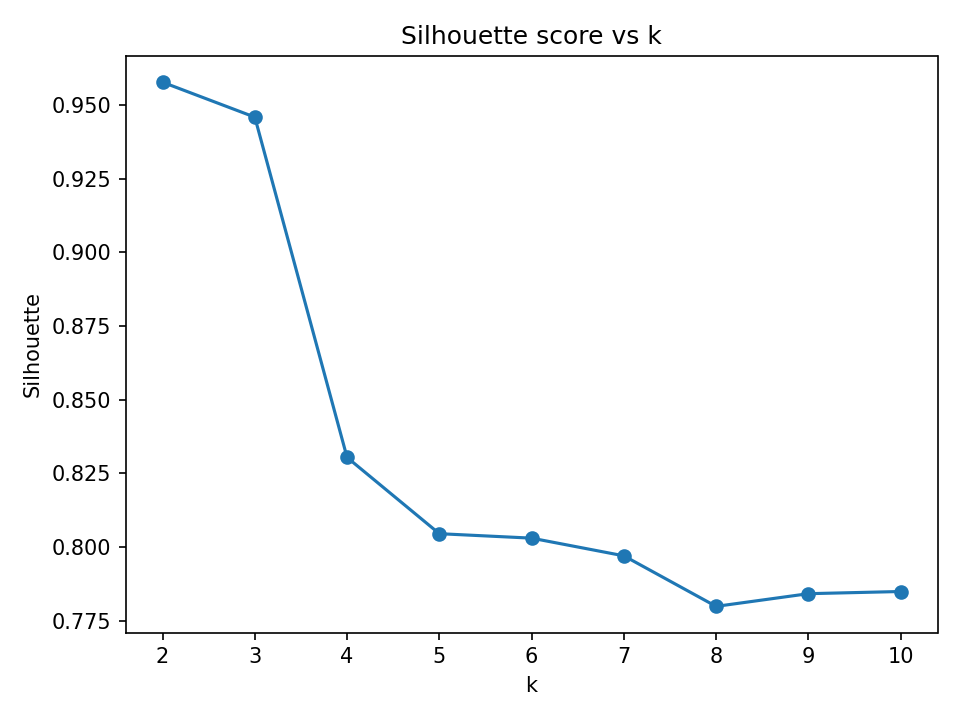

In [19]:
from pathlib import Path
from IPython.display import Image, display

plots_dir = Path("DATA/ML/plots")

pngs = [
    plots_dir / "elbow.png",
    plots_dir / "silhouette.png",
]

for p in pngs:
    if p.exists():
        display(p.name)
        display(Image(filename=str(p)))
    else:
        print(f"Файл не знайдено: {p}")


### Висновок (кластеризація SKU методом K-means)

Для сегментації PR-товарів за профілем продажів було застосовано алгоритм **K-means**.

Оптимальну кількість кластерів визначено за допомогою двох підходів:
- **метод “ліктя” (Elbow method)** — аналіз зміни інерції при збільшенні кількості кластерів;
- **метрика Silhouette score** — оцінка якості розділення об’єктів між кластерами.

На графіку Elbow спостерігається різке зменшення інерції до **k = 2**,
після чого швидкість покращення суттєво знижується.
Водночас максимальне значення Silhouette score також досягається при **k = 2**.

На основі цього було обрано **k = 2** як оптимальну кількість кластерів.
Отримані кластери дозволяють розділити SKU на дві групи з різними
характеристиками продажів, що є корисним для подальшого аналізу попиту
та прийняття управлінських рішень.


## STEP 10. ML: прогноз TOTAL (RandomForest)

Мета: показати приклад supervised ML на даних продажів.

Оскільки є лише 12 місяців історії, робимо показовий ML-кейс:
модель навчається на профілі продажів (12 місяців + Stock/Month_sales) і прогнозує `TOTAL`.

Результат:
- метрики MAE та R² (baseline vs модель)
- графіки:
  - `DATA/ML/plots/pred_vs_true.png`
  - `DATA/ML/plots/feature_importance.png`
- артефакт моделі: `DATA/ML/model_rf_total.joblib`


In [20]:
!python DATA/step10_ml_regression_total.py


STEP 10 | ML: RandomForestRegressor (прогноз TOTAL)
ML (RandomForestRegressor) — прогноз TOTAL за профілем продажів (PR-)
- Baseline (mean): MAE=3469.28, R2=-0.032
- Model (RF):      MAE=727.24, R2=0.866
OK | STEP 10 завершено
- model: DATA/ML/model_rf_total.joblib
- plots: DATA/ML/plots


## Вітрина результатів ML-моделі (RandomForest)

Нижче наведено ілюстрації результатів роботи ML-моделі:
- порівняння прогнозованих та фактичних значень TOTAL;
- важливість ознак (feature importance) у моделі RandomForest.


'pred_vs_true.png'

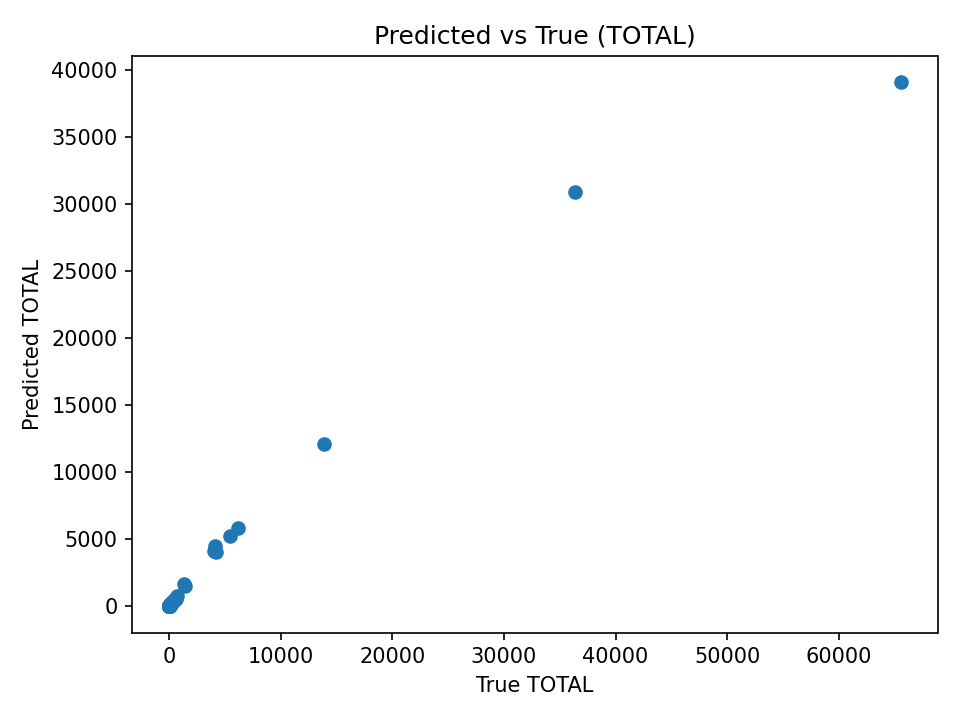

'feature_importance.png'

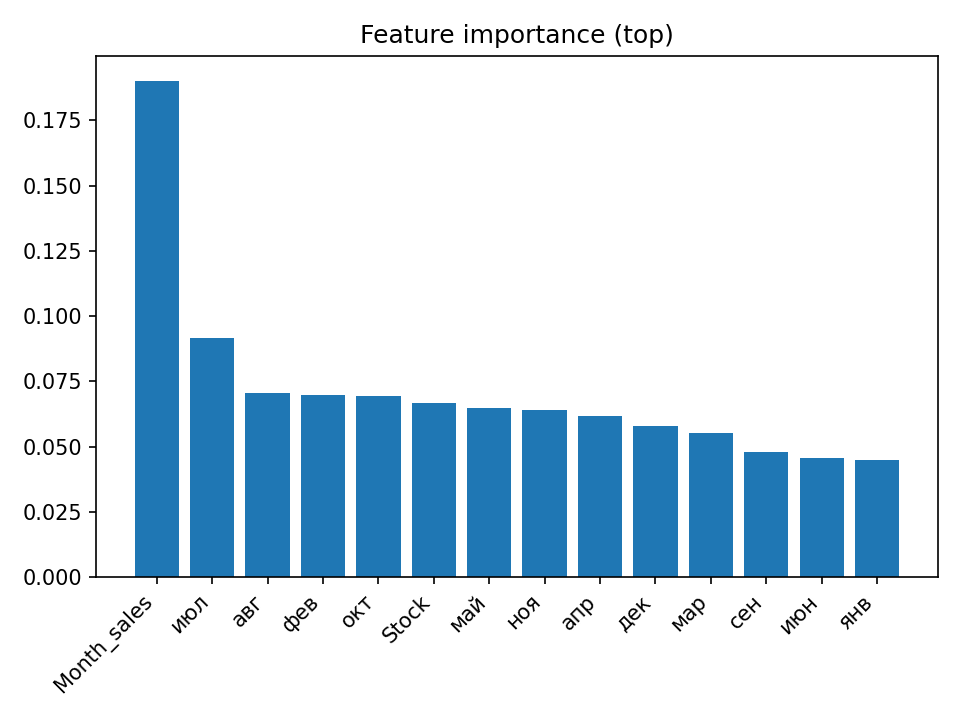

In [21]:
from pathlib import Path
from IPython.display import Image, display

plots_dir = Path("DATA/ML/plots")

pngs = [
    plots_dir / "pred_vs_true.png",
    plots_dir / "feature_importance.png",
]

for p in pngs:
    if p.exists():
        display(p.name)
        display(Image(filename=str(p)))
    else:
        print(f"Файл не знайдено: {p}")


### Інтерпретація результатів прогнозування

На графіку **Predicted vs True (TOTAL)** зображено співвідношення між
фактичними та прогнозованими значеннями сумарних продажів.

Більшість точок розташовані поблизу діагоналі, що свідчить про
високу точність прогнозу моделі RandomForest.
Особливо добре модель відтворює середні та великі значення TOTAL,
що є критично важливим з точки зору бізнес-планування.

Невеликі відхилення для окремих SKU пояснюються:
- нерівномірністю продажів,
- наявністю викидів,
- обмеженим обсягом історичних даних.


### Аналіз важливості ознак (Feature Importance)

Графік важливості ознак показує, які фактори найбільше впливають
на прогноз сумарних продажів (TOTAL) у моделі RandomForest.

Найважливішою ознакою є **Month_sales**, що логічно, оскільки
вона відображає типовий середньомісячний рівень продажів товару.
Також суттєвий вплив мають окремі місяці та показник **Stock**,
який характеризує наявність товару.

Це підтверджує, що модель виявляє інтуїтивно зрозумілі та
бізнес-логічні залежності, а не випадкові кореляції.


Результати EDA та кластеризації показали, що товари мають різні
профілі продажів і сезонність. Побудована ML-модель враховує ці
характеристики та дозволяє ефективно прогнозувати сумарні продажі,
що підтверджується високим значенням R² та низькою помилкою MAE.


# Висновок
В результаті дипломної рооти побудувано пайплайн аналізу продажів: від нормалізації даних і EDA, через кластеризацію SKU, до прогнозування сумарних продажів за допомогою ML. RandomForest показав значно кращі результати порівняно з базовою моделлю, що підтверджує наявність складних нелінійних залежностей у даних.